In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FsYWwvRGVza3RvcC9jb2RlL2NyYWJieW1ldHJpY3MvZG9jcy9hYmxhdGlvbnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap.py": 1743382022.7735002, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap_external.py": 1743382022.7737157, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/zipimport.py": 1743382022.8471594, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/codecs.py": 1743382022.716922, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/aliases.py": 1743382022.7266889, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/__init__.py": 1743382022.7262201, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/utf_8.py": 1743382022.7358487, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/abc.py": 1743382022.7091

In [2]:
from html import escape

import matplotlib.pyplot as plt
import numpy as np

import crabbymetrics as cm
from IPython.display import HTML, display

np.set_printoptions(precision=4, suppress=True)


def html_table(headers, rows):
    parts = [
        "<table>",
        "<thead>",
        "<tr>",
        *[f"<th>{escape(str(header))}</th>" for header in headers],
        "</tr>",
        "</thead>",
        "<tbody>",
    ]
    for row in rows:
        parts.append("<tr>")
        for cell in row:
            parts.append(f"<td>{cell}</td>")
        parts.append("</tr>")
    parts.extend(["</tbody>", "</table>"])
    return "".join(parts)


def summarize_method(estimates, ses, truth):
    estimates = np.asarray(estimates)
    ses = np.asarray(ses)
    covered = np.abs(estimates - truth) <= 1.96 * ses
    return {
        "mean_estimate": float(estimates.mean()),
        "bias": float(estimates.mean() - truth),
        "empirical_sd": float(estimates.std(ddof=1)),
        "mean_se": float(ses.mean()),
        "coverage": float(covered.mean()),
        "mean_ci_length": float((2.0 * 1.96 * ses).mean()),
    }


def build_result_rows(results, model_name):
    rows = []
    for entry in results:
        rows.append(
            [
                model_name,
                entry["method"],
                entry["n"],
                f"{entry['mean_estimate']:.4f}",
                f"{entry['bias']:.4f}",
                f"{entry['empirical_sd']:.4f}",
                f"{entry['mean_se']:.4f}",
                f"{entry['coverage']:.3f}",
                f"{entry['mean_ci_length']:.4f}",
            ]
        )
    return rows


def plot_coverages(ax, results, title):
    sample_sizes = sorted({entry["n"] for entry in results})
    methods = []
    for entry in results:
        if entry["method"] not in methods:
            methods.append(entry["method"])

    for method in methods:
        coverage = [
            next(entry["coverage"] for entry in results if entry["n"] == n and entry["method"] == method)
            for n in sample_sizes
        ]
        ax.plot(sample_sizes, coverage, marker="o", linewidth=2.0, label=method)

    ax.axhline(0.95, color="black", linestyle="--", linewidth=1.0)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(title)
    ax.set_xlabel("Sample size")
    ax.set_ylabel("95% CI coverage")
    ax.legend()

In [3]:
sample_sizes = [100, 400, 1600]
ols_reps = 3000
poisson_reps = 700
gmm_reps = 700

display(
    HTML(
        html_table(
            ["Experiment", "Replications Per n", "Target"],
            [
                ["OLS", ols_reps, "Slope on the first regressor"],
                ["Poisson", poisson_reps, "Slope on the first regressor"],
                ["GMM", gmm_reps, "Coefficient on the endogenous regressor"],
            ],
        )
    )
)

Experiment,Replications Per n,Target
OLS,3000,Slope on the first regressor
Poisson,700,Slope on the first regressor
GMM,700,Coefficient on the endogenous regressor


In [4]:
def simulate_ols(sample_sizes, reps, seed):
    rng = np.random.default_rng(seed)
    beta_true = np.array([0.5, 1.0, -0.6])
    out = []

    for n in sample_sizes:
        slope_estimates = []
        vanilla_ses = []
        hc1_ses = []

        for _ in range(reps):
            x = rng.normal(size=(n, 2))
            sigma = 0.4 + 0.9 * x[:, 0] ** 2
            y = beta_true[0] + x @ beta_true[1:] + sigma * rng.normal(size=n)
            model = cm.OLS()
            model.fit(x, y)
            vanilla = model.summary(vcov="vanilla")
            hc1 = model.summary(vcov="hc1")

            slope_estimates.append(float(vanilla["coef"][0]))
            vanilla_ses.append(float(vanilla["coef_se"][0]))
            hc1_ses.append(float(hc1["coef_se"][0]))

        out.append({"n": n, "method": "Vanilla", **summarize_method(slope_estimates, vanilla_ses, beta_true[1])})
        out.append({"n": n, "method": "HC1", **summarize_method(slope_estimates, hc1_ses, beta_true[1])})

    return out


def simulate_poisson(sample_sizes, reps, seed):
    rng = np.random.default_rng(seed)
    beta_true = np.array([0.2, 0.4, -0.3])
    out = []

    for n in sample_sizes:
        slope_estimates = []
        vanilla_ses = []
        qmle_ses = []

        for _ in range(reps):
            x = rng.normal(size=(n, 2))
            design = np.column_stack([np.ones(n), x])
            mu = np.exp(design @ beta_true)
            mixing = rng.gamma(shape=2.0, scale=0.5, size=n)
            y = rng.poisson(mu * mixing).astype(float)

            model = cm.Poisson(alpha=0.0, max_iterations=200, tolerance=1e-8)
            model.fit(x, y)
            vanilla = model.summary(vcov="vanilla")
            qmle = model.summary(vcov="sandwich")

            slope_estimates.append(float(vanilla["coef"][0]))
            vanilla_ses.append(float(vanilla["coef_se"][0]))
            qmle_ses.append(float(qmle["coef_se"][0]))

        out.append(
            {"n": n, "method": "Vanilla Fisher", **summarize_method(slope_estimates, vanilla_ses, beta_true[1])}
        )
        out.append(
            {"n": n, "method": "QMLE Sandwich", **summarize_method(slope_estimates, qmle_ses, beta_true[1])}
        )

    return out


def gmm_moments(theta, data):
    resid = data["y"] - data["x"] * theta[0]
    return data["z"] * resid[:, None]


def gmm_jacobian(theta, data):
    del theta
    return -(data["z"].T @ data["x"][:, None]) / data["x"].shape[0]


def simulate_gmm(sample_sizes, reps, seed):
    rng = np.random.default_rng(seed)
    beta_true = 1.0
    out = []

    for n in sample_sizes:
        slope_estimates = []
        vanilla_ses = []
        sandwich_ses = []

        for _ in range(reps):
            z = rng.normal(size=(n, 3))
            v = rng.normal(size=n)
            eps = rng.normal(size=n)
            x = z @ np.array([0.9, 0.45, -0.35]) + v
            u = (0.3 + 0.5 * z[:, 0] ** 2) * eps + 0.6 * v
            y = beta_true * x + u

            zx = z.T @ x
            zy = z.T @ y
            theta0 = np.array([(zx @ zy) / (zx @ zx)])

            model = cm.GMM(gmm_moments, jacobian_fn=gmm_jacobian, max_iterations=200, tolerance=1e-10)
            model.fit({"x": x, "y": y, "z": z}, theta0, weighting="identity")

            vanilla = model.summary(vcov="vanilla")
            sandwich = model.summary(vcov="sandwich", omega="iid")
            slope_estimates.append(float(vanilla["coef"][0]))
            vanilla_ses.append(float(vanilla["se"][0]))
            sandwich_ses.append(float(sandwich["se"][0]))

        out.append({"n": n, "method": "Vanilla", **summarize_method(slope_estimates, vanilla_ses, beta_true)})
        out.append({"n": n, "method": "Sandwich", **summarize_method(slope_estimates, sandwich_ses, beta_true)})

    return out

In [5]:
ols_results = simulate_ols(sample_sizes, ols_reps, seed=20260322)
poisson_results = simulate_poisson(sample_sizes, poisson_reps, seed=20260323)
gmm_results = simulate_gmm(sample_sizes, gmm_reps, seed=20260324)

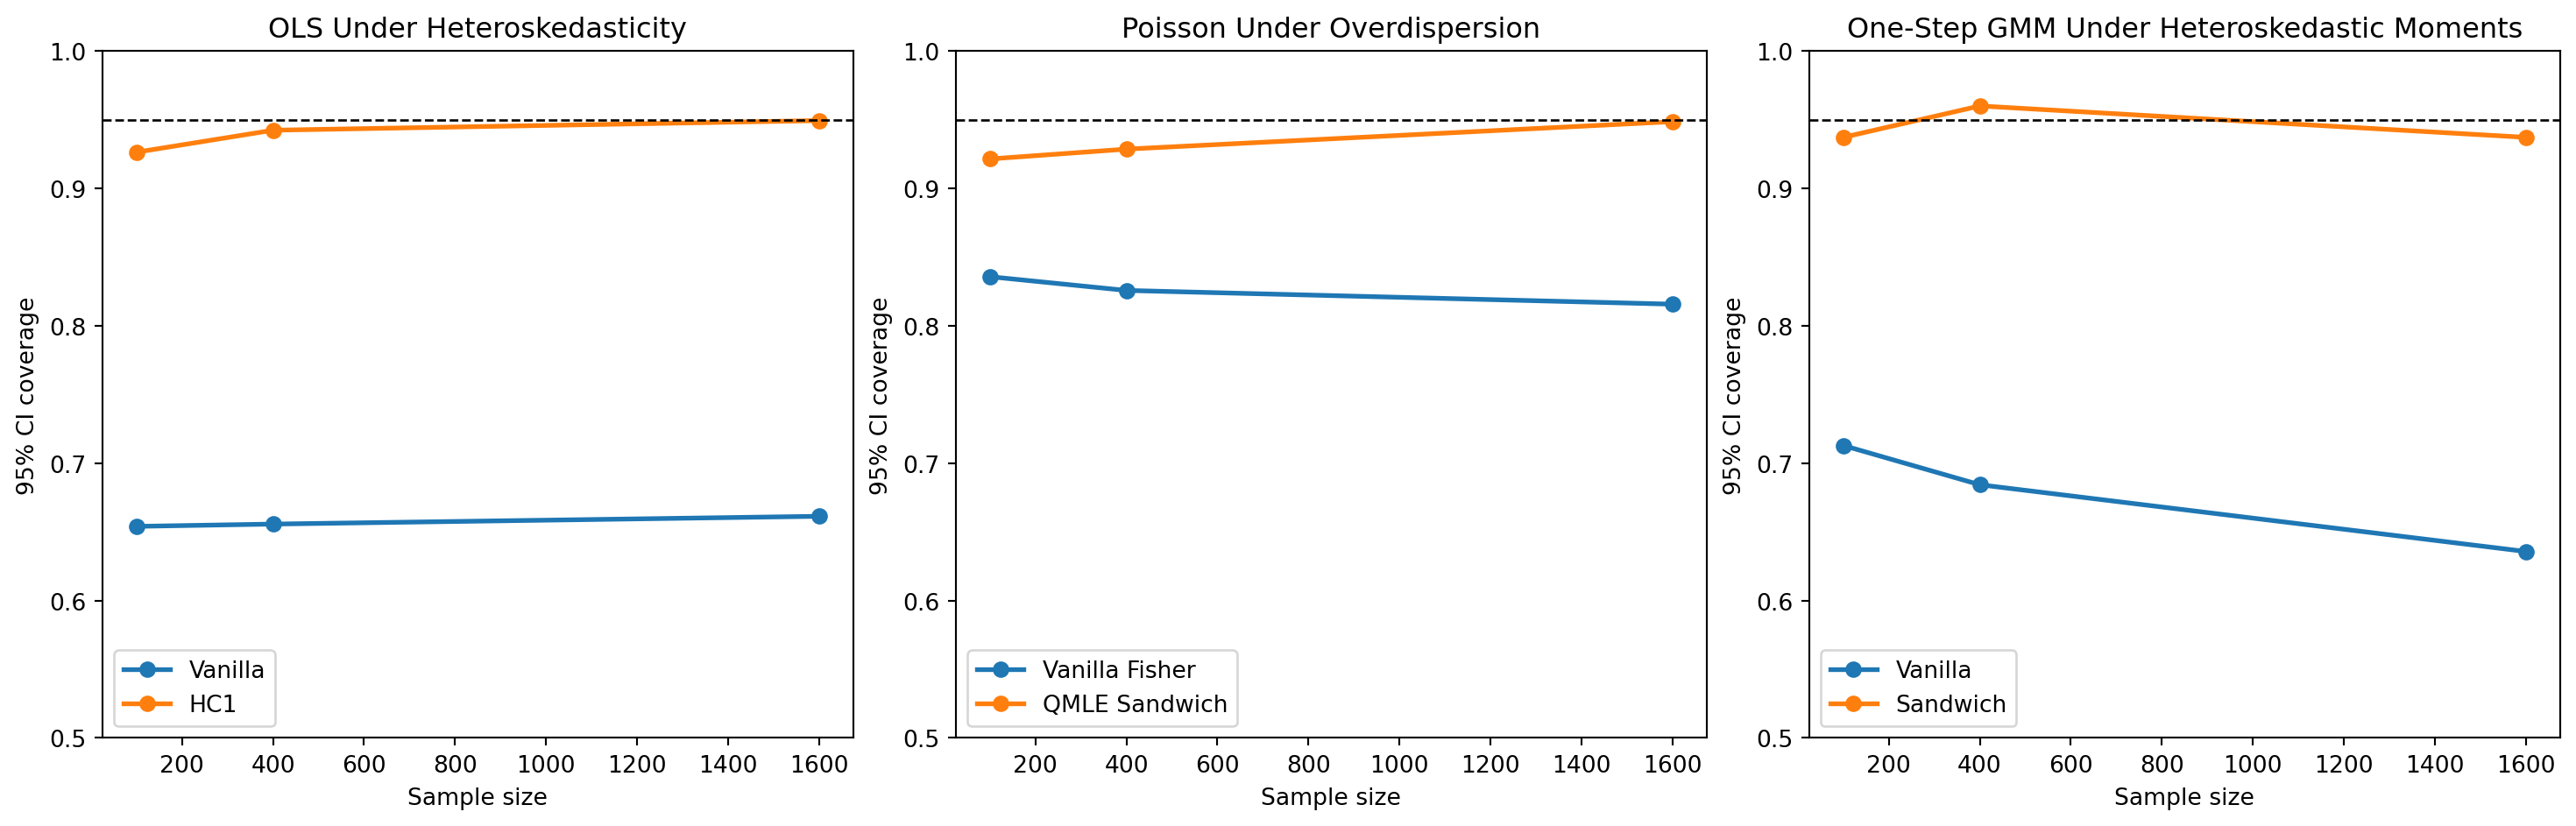

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.8), constrained_layout=True)
plot_coverages(axes[0], ols_results, "OLS Under Heteroskedasticity")
plot_coverages(axes[1], poisson_results, "Poisson Under Overdispersion")
plot_coverages(axes[2], gmm_results, "One-Step GMM Under Heteroskedastic Moments")
plt.show()

In [7]:
display(
    HTML(
        html_table(
            ["Model", "Method", "n", "Mean Estimate", "Bias", "Empirical SD", "Mean SE", "Coverage", "Mean CI Length"],
            build_result_rows(ols_results, "OLS"),
        )
    )
)

Model,Method,n,Mean Estimate,Bias,Empirical SD,Mean SE,Coverage,Mean CI Length
OLS,Vanilla,100,0.9826,-0.0174,0.3730,0.1762,0.654,0.6906
OLS,HC1,100,0.9826,-0.0174,0.3730,0.3347,0.926,1.3122
OLS,Vanilla,400,0.9974,-0.0026,0.1897,0.0904,0.656,0.3543
OLS,HC1,400,0.9974,-0.0026,0.1897,0.1831,0.942,0.7178
OLS,Vanilla,1600,0.9973,-0.0027,0.0947,0.0454,0.661,0.1781
OLS,HC1,1600,0.9973,-0.0027,0.0947,0.0943,0.949,0.3698


In [8]:
display(
    HTML(
        html_table(
            ["Model", "Method", "n", "Mean Estimate", "Bias", "Empirical SD", "Mean SE", "Coverage", "Mean CI Length"],
            build_result_rows(poisson_results, "Poisson"),
        )
    )
)

Model,Method,n,Mean Estimate,Bias,Empirical SD,Mean SE,Coverage,Mean CI Length
Poisson,Vanilla Fisher,100,0.4021,0.0021,0.1230,0.0875,0.836,0.3431
Poisson,QMLE Sandwich,100,0.4021,0.0021,0.1230,0.1125,0.921,0.4412
Poisson,Vanilla Fisher,400,0.3947,-0.0053,0.0613,0.0427,0.826,0.1675
Poisson,QMLE Sandwich,400,0.3947,-0.0053,0.0613,0.0586,0.929,0.2296
Poisson,Vanilla Fisher,1600,0.3989,-0.0011,0.0299,0.0213,0.816,0.0836
Poisson,QMLE Sandwich,1600,0.3989,-0.0011,0.0299,0.0299,0.949,0.1172


In [9]:
display(
    HTML(
        html_table(
            ["Model", "Method", "n", "Mean Estimate", "Bias", "Empirical SD", "Mean SE", "Coverage", "Mean CI Length"],
            build_result_rows(gmm_results, "GMM"),
        )
    )
)

Model,Method,n,Mean Estimate,Bias,Empirical SD,Mean SE,Coverage,Mean CI Length
GMM,Vanilla,100,1.0071,0.0071,0.1787,0.0943,0.713,0.3695
GMM,Sandwich,100,1.0071,0.0071,0.1787,0.1702,0.937,0.6672
GMM,Vanilla,400,0.9982,-0.0018,0.0928,0.0470,0.684,0.1842
GMM,Sandwich,400,0.9982,-0.0018,0.0928,0.0914,0.960,0.3582
GMM,Vanilla,1600,0.9978,-0.0022,0.0505,0.0235,0.636,0.0922
GMM,Sandwich,1600,0.9978,-0.0022,0.0505,0.0472,0.937,0.1849
